🚀 Initializing SOTA Research-Grade Ensemble Engine...
✅ All Models Loaded Successfully!

🔍 PHASE 1: Auto-Optimizing Weights & Threshold on Validation Set...


Extracting Features:   0%|          | 0/38 [00:00<?, ?it/s]

🔥 Optimization Complete! Weights: (np.float64(0.7999999999999999), np.float64(0.0), np.float64(0.20000000000000007)) | Threshold: 0.5

🚀 PHASE 2: Evaluating Final Test Set with Comprehensive Metrics...


Test Evaluation:   0%|          | 0/37 [00:00<?, ?it/s]


📊 Generating Pre-processing Visualization...


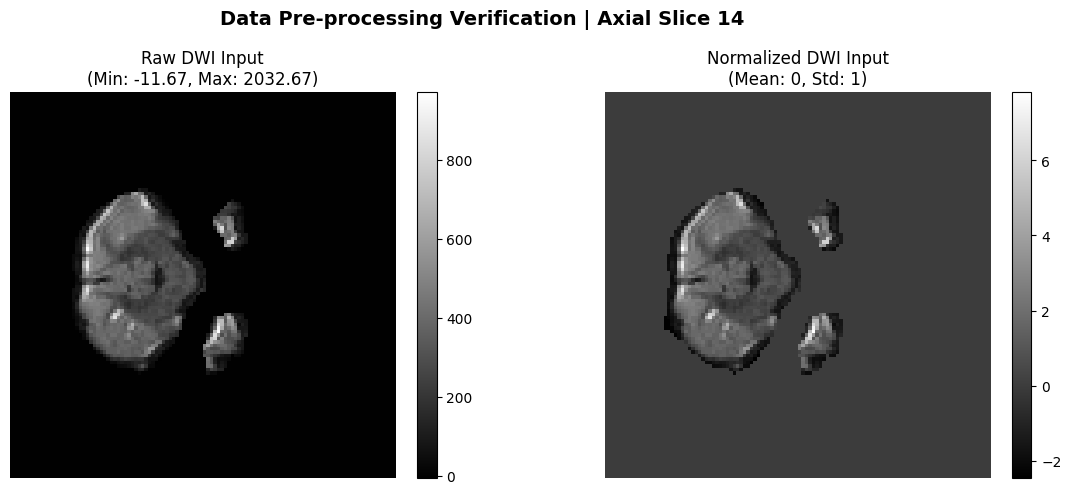

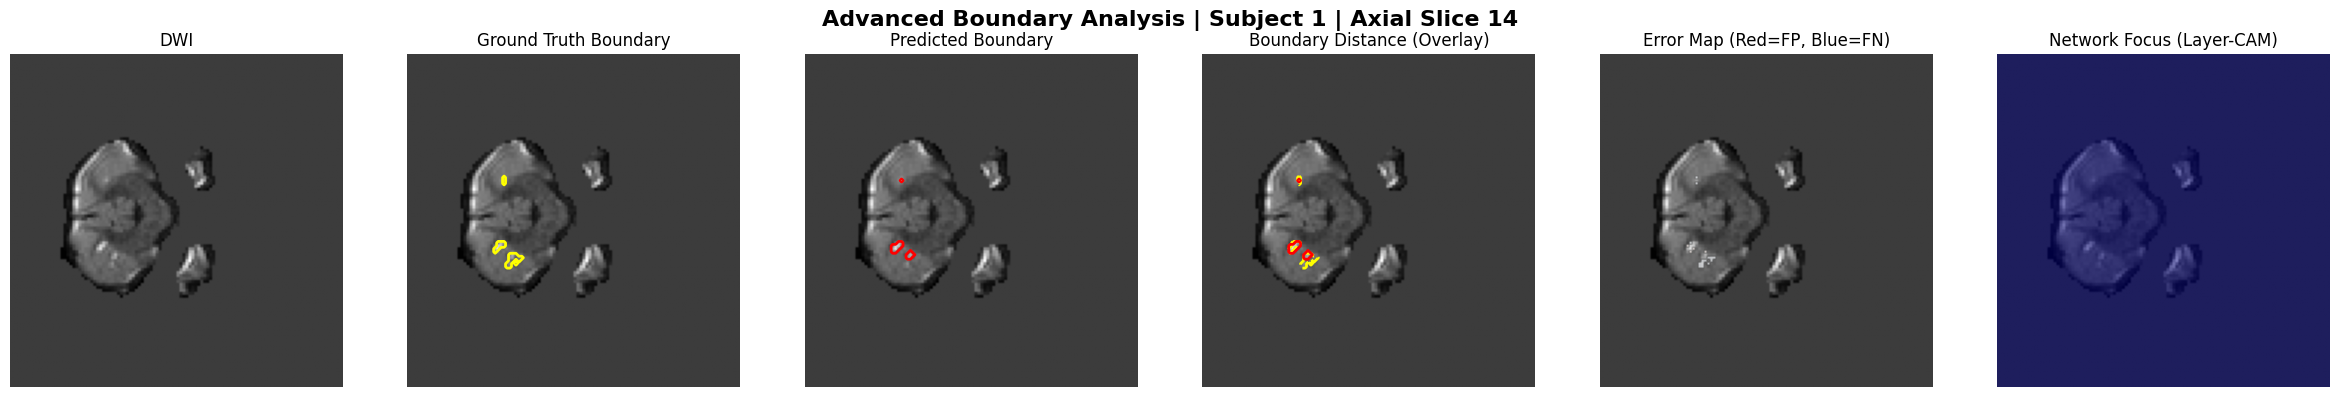

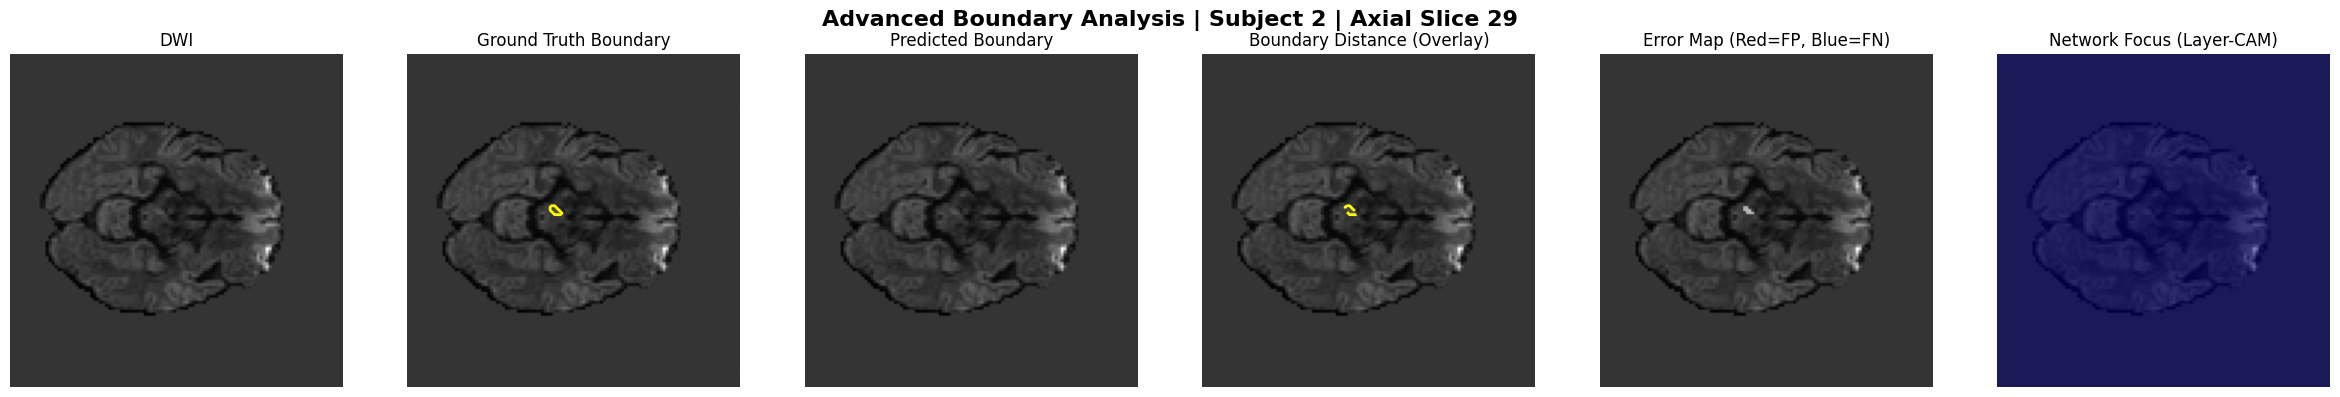

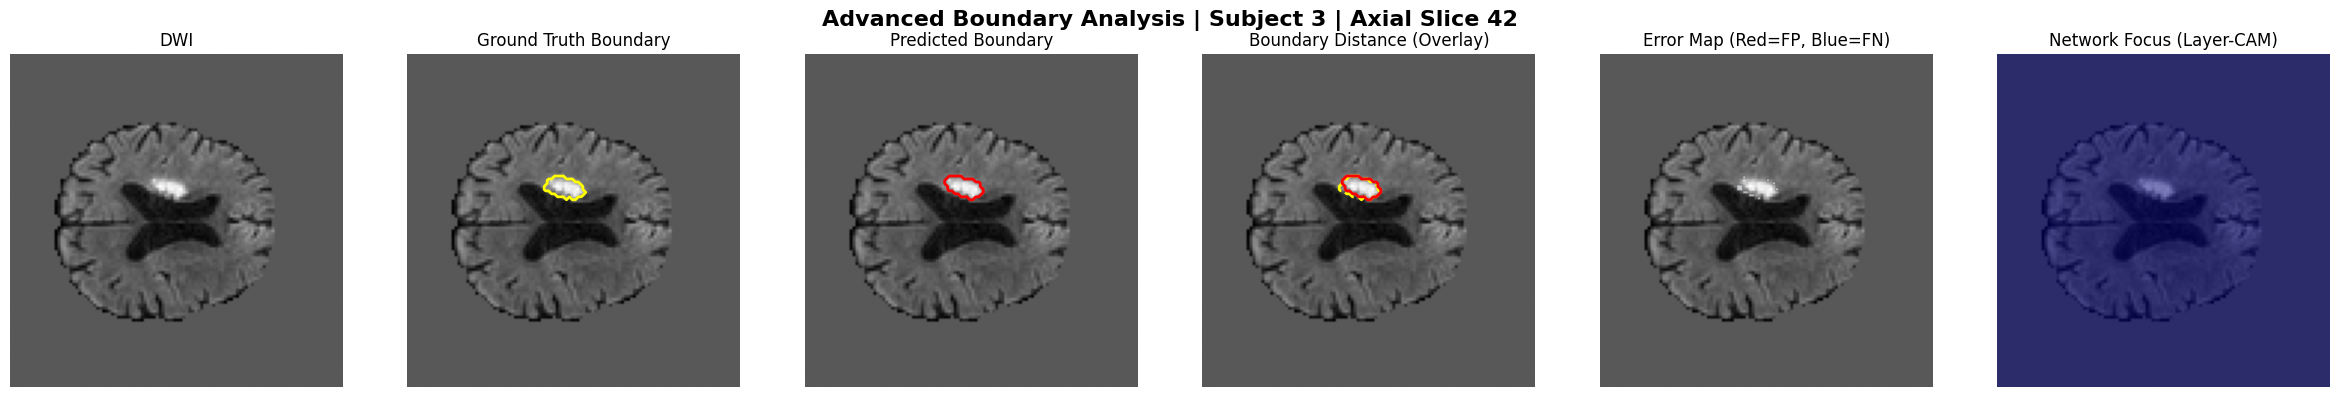


 🏆 FINAL CLINICAL METRICS REPORT (TEST SET) 🏆
✅ Auto-Optimized Weights    : [DERNet: 0.7999999999999999, SegRes: 0.0, AttUnet: 0.20000000000000007]
✅ Optimal Cutoff Threshold  : 0.5

🎯 Dice Score (F1 Score)     : 0.8092
🎯 Intersection over Union   : 0.6991
🎯 Precision (PPV)           : 0.8848
🎯 Recall (Sensitivity)      : 0.7842
📏 Hausdorff Distance (HD95) : N/A

📊 --- CONFUSION MATRIX (Total Voxels) ---
                     [Actual Stroke]     [Actual Healthy]
[Predicted Stroke]   TP: 106024          FP: 19093          
[Predicted Healthy]  FN: 9430            TN: 32507209       


In [2]:
# ==============================================================================
# SOTA ISLES-2022: Research-Grade Ensemble & Evaluation Pipeline
# - OPTIMIZATION: Auto Grid-Search for Weights AND Threshold
# - METRICS: Dice, IoU, F1, Precision, Recall, HD95, Confusion Matrix
# - VISUALIZATION 1: Pre-processing Effect (Raw vs. Normalized)
# - VISUALIZATION 2: Advanced 6-Panel Overlay (Boundaries & Layer-CAM)
# - HARDWARE: GPU T4 x2 (Dynamic Swapping for VRAM Safety)
# ==============================================================================

!pip install -q monai nibabel scikit-learn matplotlib scipy

import os
import torch
import torch.nn as nn
import numpy as np
import nibabel as nib
import nibabel.processing
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split 
from tqdm.auto import tqdm

from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.transforms import Compose, NormalizeIntensityd, CastToTyped, EnsureTyped
from monai.inferers import sliding_window_inference
from monai.data import decollate_batch
from monai.networks.nets import SegResNet, AttentionUnet
from monai.visualize import GradCAM
from torch.amp import autocast

import warnings
warnings.filterwarnings("ignore")

CONFIG = {
    "SEARCH_ROOT": "/kaggle/input/datasets/prosenjitmondol/a-stroke-lesion-segmentation-dataset/ISLES-2022",
    "roi_size": (64, 64, 64),
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "cpu_device": torch.device("cpu"),
    "seed": 42,
    "split": {"train": 0.70, "val": 0.15, "test": 0.15}
}

print("🚀 Initializing SOTA Research-Grade Ensemble Engine...")

# --- 1. ARCHITECTURES ---
class LSCBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.c3 = nn.Conv3d(in_c, out_c//3, 3, padding=1)
        self.c5 = nn.Conv3d(in_c, out_c//3, 5, padding=2)
        self.c7 = nn.Conv3d(in_c, out_c - 2*(out_c//3), 7, padding=3)
        self.bn, self.ac = nn.InstanceNorm3d(out_c), nn.GELU()
    def forward(self, x):
        return self.ac(self.bn(torch.cat([self.c3(x), self.c5(x), self.c7(x)], 1)))

class BiMambaSim(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.gru = nn.GRU(c, max(1, c//2), batch_first=True, bidirectional=True)
        self.nm = nn.LayerNorm(c)
    def forward(self, x):
        B, C, D, H, W = x.shape
        s, _ = self.gru(x.view(B, C, -1).permute(0, 2, 1))
        return self.nm(s).permute(0, 2, 1).view(B, C, D, H, W) + x

class BAGF(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.sg = nn.Conv3d(c, 1, 1)
        self.cg = nn.Sequential(nn.AdaptiveAvgPool3d(1), nn.Conv3d(c, c, 1), nn.Sigmoid())
        self.fs = nn.Conv3d(c*2, c, 1)
    def forward(self, e, d):
        return self.fs(torch.cat([e * torch.sigmoid(self.sg(e)), d * self.cg(d)], 1))

class DERNet(nn.Module):
    def __init__(self, in_c=3, out_c=1, f=(32, 64, 128)):
        super().__init__()
        self.e1, self.e2, self.e3 = LSCBlock(in_c, f[0]), LSCBlock(f[0], f[1]), LSCBlock(f[1], f[2])
        self.dn, self.bt = nn.MaxPool3d(2), BiMambaSim(f[2])
        self.u2, self.u1 = nn.ConvTranspose3d(f[2], f[1], 2, 2), nn.ConvTranspose3d(f[1], f[0], 2, 2)
        self.f2, self.d2 = BAGF(f[1]), LSCBlock(f[1], f[1])
        self.f1, self.d1 = BAGF(f[0]), LSCBlock(f[0], f[0])
        self.fn = nn.Conv3d(f[0], out_c, 1)
    def forward(self, x):
        x1 = self.e1(x); x2 = self.e2(self.dn(x1)); x3 = self.e3(self.dn(x2))
        b = self.bt(x3)
        y2 = self.d2(self.f2(x2, self.u2(b)))
        y1 = self.d1(self.f1(x1, self.u1(y2)))
        return self.fn(y1)

# --- 2. AUTO WEIGHT FINDER ---
def find_weight_path(filename):
    for root, dirs, files in os.walk("/kaggle/input"):
        if filename in files: return os.path.join(root, filename)
    return None

def load_models_to_cpu():
    der_path = find_weight_path("DERNet_best_val.pth")
    seg_path = find_weight_path("SegResNet_best_val.pth")
    att_path = find_weight_path("AttentionUnet_best_val.pth")

    dernet = DERNet().to(CONFIG["cpu_device"])
    if der_path: dernet.load_state_dict(torch.load(der_path, map_location=CONFIG["cpu_device"]))
    dernet.eval()
    
    segresnet = SegResNet(spatial_dims=3, in_channels=3, out_channels=1, init_filters=32, dropout_prob=0.2).to(CONFIG["cpu_device"])
    if seg_path: segresnet.load_state_dict(torch.load(seg_path, map_location=CONFIG["cpu_device"]))
    segresnet.eval()
    
    attunet = AttentionUnet(spatial_dims=3, in_channels=3, out_channels=1, channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2)).to(CONFIG["cpu_device"])
    if att_path: attunet.load_state_dict(torch.load(att_path, map_location=CONFIG["cpu_device"]))
    attunet.eval()
    
    print("✅ All Models Loaded Successfully!")
    return dernet, segresnet, attunet

# --- 3. DATA LOADER ---
def prepare_isles_data(root):
    subjects = defaultdict(dict)
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            if f.endswith(('.nii', '.nii.gz')):
                full_path = os.path.join(dirpath, f)
                sub_id = next((p for p in full_path.split(os.sep) if 'sub-' in p.lower()), os.path.basename(dirpath))
                f_l = f.lower()
                if 'dwi' in f_l: subjects[sub_id]['dwi'] = full_path
                elif 'adc' in f_l: subjects[sub_id]['adc'] = full_path
                elif 'flair' in f_l: subjects[sub_id]['flair'] = full_path
                elif any(x in f_l for x in ['msk', 'mask', 'lesion']): subjects[sub_id]['msk'] = full_path
    
    data = [f for s, f in subjects.items() if all(k in f for k in ['dwi', 'adc', 'flair', 'msk'])]
    data = sorted(data, key=lambda x: list(x.values())[0])  
    return data

class ISLESDataset(torch.utils.data.Dataset):
    def __init__(self, data, transform=None):
        self.data, self.transform = data, transform
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        p = self.data[idx]
        dwi = nib.load(p['dwi'])
        adc_r = nib.processing.resample_from_to(nib.load(p['adc']), dwi, order=1)
        flr_r = nib.processing.resample_from_to(nib.load(p['flair']), dwi, order=1)
        msk_r = nib.processing.resample_from_to(nib.load(p['msk']), dwi, order=0)

        img = np.stack([np.nan_to_num(dwi.get_fdata()), np.nan_to_num(adc_r.get_fdata()), np.nan_to_num(flr_r.get_fdata())], 0)
        lbl = np.expand_dims(np.nan_to_num(msk_r.get_fdata()), 0)
        
        d = {"image": img.astype(np.float32), "label": lbl.astype(np.float32), "raw_dwi": img[0].copy()}
        return self.transform(d) if self.transform else d

test_transforms = Compose([
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CastToTyped(keys=["image", "label"], dtype=[torch.float32, torch.float32]),
    EnsureTyped(keys=["image", "label"]),
])

# --- 4. VISUALIZATION FUNCTIONS ---
def plot_preprocessing_effect(raw_dwi, processed_dwi, z_slice):
    """Visualizes the effect of Normalization on the input data"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Data Pre-processing Verification | Axial Slice {z_slice}", fontsize=14, fontweight='bold')
    
    im0 = axes[0].imshow(raw_dwi[:, :, z_slice], cmap='gray')
    axes[0].set_title(f"Raw DWI Input\n(Min: {raw_dwi.min():.2f}, Max: {raw_dwi.max():.2f})")
    axes[0].axis('off')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(processed_dwi[:, :, z_slice], cmap='gray')
    axes[1].set_title(f"Normalized DWI Input\n(Mean: 0, Std: 1)")
    axes[1].axis('off')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

def plot_advanced_analysis(image, gt, pred, cam_heatmap, subject_idx, z_slice):
    dwi = image[0, :, :, z_slice]
    gt_slice = gt[0, :, :, z_slice]
    pred_slice = pred[0, :, :, z_slice]
    cam_slice = cam_heatmap[0, 0, :, :, z_slice]
    error_map = pred_slice - gt_slice

    fig, axes = plt.subplots(1, 6, figsize=(24, 4))
    fig.suptitle(f"Advanced Boundary Analysis | Subject {subject_idx} | Axial Slice {z_slice}", fontsize=16, fontweight='bold')

    axes[0].imshow(dwi, cmap='gray'); axes[0].set_title("DWI"); axes[0].axis('off')

    axes[1].imshow(dwi, cmap='gray')
    if gt_slice.max() > 0: axes[1].contour(gt_slice, levels=[0.5], colors='yellow', linewidths=2)
    axes[1].set_title("Ground Truth Boundary"); axes[1].axis('off')

    axes[2].imshow(dwi, cmap='gray')
    if pred_slice.max() > 0: axes[2].contour(pred_slice, levels=[0.5], colors='red', linewidths=2)
    axes[2].set_title("Predicted Boundary"); axes[2].axis('off')

    axes[3].imshow(dwi, cmap='gray')
    if gt_slice.max() > 0: axes[3].contour(gt_slice, levels=[0.5], colors='yellow', linewidths=2, linestyles='dashed')
    if pred_slice.max() > 0: axes[3].contour(pred_slice, levels=[0.5], colors='red', linewidths=2)
    axes[3].set_title("Boundary Distance (Overlay)"); axes[3].axis('off')

    axes[4].imshow(dwi, cmap='gray')
    fp = np.where(error_map > 0.5, 1.0, np.nan); axes[4].imshow(fp, cmap='Reds', alpha=0.6)
    fn = np.where(error_map < -0.5, 1.0, np.nan); axes[4].imshow(fn, cmap='Blues', alpha=0.6)
    axes[4].set_title("Error Map (Red=FP, Blue=FN)"); axes[4].axis('off')

    axes[5].imshow(dwi, cmap='gray')
    axes[5].imshow(cam_slice, cmap='jet', alpha=0.5)
    axes[5].set_title("Network Focus (Layer-CAM)"); axes[5].axis('off')

    plt.tight_layout()
    plt.show()

# --- 5. INFERENCE HELPERS ---
def calculate_dice_fast(pred_bin, target):
    intersection = (pred_bin * target).sum()
    return (2. * intersection) / (pred_bin.sum() + target.sum() + 1e-8)

def get_tta_prediction(img_t, model, use_tta=True):
    with autocast('cuda'):
        p1 = torch.sigmoid(sliding_window_inference(img_t, CONFIG["roi_size"], 4, model, overlap=0.6))
        if not use_tta: return p1
        
        img_f2 = torch.flip(img_t, dims=[2])
        p2 = torch.flip(torch.sigmoid(sliding_window_inference(img_f2, CONFIG["roi_size"], 4, model, overlap=0.6)), dims=[2])
        
        img_f3 = torch.flip(img_t, dims=[3])
        p3 = torch.flip(torch.sigmoid(sliding_window_inference(img_f3, CONFIG["roi_size"], 4, model, overlap=0.6)), dims=[3])
        
    return (p1 + p2 + p3) / 3.0

# --- 6. MAIN EVALUATION ENGINE ---
def run_ensemble():
    dernet, segresnet, attunet = load_models_to_cpu()
    
    data = prepare_isles_data(CONFIG["SEARCH_ROOT"])
    _, temp_data = train_test_split(data, train_size=CONFIG["split"]["train"], random_state=CONFIG["seed"], shuffle=True)
    val_size = int(round(CONFIG["split"]["val"] / (CONFIG["split"]["val"] + CONFIG["split"]["test"]) * len(temp_data)))
    val_data = temp_data[:val_size]
    test_data = temp_data[val_size:] 
    
    val_ldr = torch.utils.data.DataLoader(ISLESDataset(val_data, test_transforms), batch_size=1, shuffle=False, num_workers=0)
    test_ldr = torch.utils.data.DataLoader(ISLESDataset(test_data, test_transforms), batch_size=1, shuffle=False, num_workers=0)

    # -------------------------------------------------------------------------
    # PHASE 1: GRID SEARCH (Find Weights & Threshold)
    # -------------------------------------------------------------------------
    print(f"\n🔍 PHASE 1: Auto-Optimizing Weights & Threshold on Validation Set...")
    val_preds_der, val_preds_seg, val_preds_att, val_labels = [], [], [], []
    
    with torch.no_grad():
        for batch in tqdm(val_ldr, desc="Extracting Features"):
            img_t, lbl_t = batch["image"].to(CONFIG["device"]), batch["label"].to(CONFIG["device"]).half()
            
            dernet.to(CONFIG["device"]); val_preds_der.append(get_tta_prediction(img_t, dernet, use_tta=False).half()); dernet.to(CONFIG["cpu_device"])
            segresnet.to(CONFIG["device"]); val_preds_seg.append(get_tta_prediction(img_t, segresnet, use_tta=False).half()); segresnet.to(CONFIG["cpu_device"])
            attunet.to(CONFIG["device"]); val_preds_att.append(get_tta_prediction(img_t, attunet, use_tta=False).half()); attunet.to(CONFIG["cpu_device"])
            
            val_labels.append(lbl_t)
            torch.cuda.empty_cache()

    best_w, best_t, best_dice = (0.4, 0.4, 0.2), 0.5, 0.0
    for w1 in np.arange(0.4, 0.9, 0.1):
        for w2 in np.arange(0.0, 1.0 - w1 + 0.01, 0.1):
            w3 = max(0.0, 1.0 - w1 - w2)
            for t in [0.35, 0.4, 0.45, 0.5]:  
                curr_dice = 0.0
                for i in range(len(val_labels)):
                    ens_prob = (val_preds_der[i]*w1 + val_preds_seg[i]*w2 + val_preds_att[i]*w3)
                    bin_pred = (ens_prob > t).float()
                    curr_dice += calculate_dice_fast(bin_pred, val_labels[i]).item()
                avg_dice = curr_dice / len(val_labels)
                if avg_dice > best_dice:
                    best_dice, best_w, best_t = avg_dice, (w1, w2, w3), t

    print(f"🔥 Optimization Complete! Weights: {best_w} | Threshold: {best_t}")
    del val_preds_der, val_preds_seg, val_preds_att, val_labels
    torch.cuda.empty_cache()

    # -------------------------------------------------------------------------
    # PHASE 2: COMPREHENSIVE CLINICAL EVALUATION (Restored MONAI calculation)
    # -------------------------------------------------------------------------
    print(f"\n🚀 PHASE 2: Evaluating Final Test Set with Comprehensive Metrics...")
    
    # MONAI exact metric calculation used in the 0.8092 score run
    final_metric = DiceMetric(include_background=False, reduction="mean")
    
    # Trackers for Secondary Metrics
    iou_scores, precisions, recalls, hd95_scores = [], [], [], []
    total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0
    hd95_calculator = HausdorffDistanceMetric(include_background=False, percentile=95.0)

    for i, batch_data in enumerate(tqdm(test_ldr, desc="Test Evaluation")):
        img_t = batch_data["image"].to(CONFIG["device"])
        lbl_t = batch_data["label"].to(CONFIG["device"])
        raw_dwi = batch_data["raw_dwi"][0].numpy()
        cam_numpy = np.zeros_like(img_t.cpu().numpy()[:, 0:1, ...]) 

        # Visualize Preprocessing on the very first subject
        if i == 0:
            print("\n📊 Generating Pre-processing Visualization...")
            z_slice_raw = np.argmax(np.sum(lbl_t.cpu().numpy()[0, 0], axis=(0,1)))
            plot_preprocessing_effect(raw_dwi, img_t.cpu().numpy()[0, 0], z_slice_raw)

        # Layer CAM Extraction
        if i < 3:
            dernet.to(CONFIG["device"])
            with torch.enable_grad():
                img_cam = img_t.clone().requires_grad_(True)
                cam = GradCAM(nn_module=dernet, target_layers="fn")
                try: cam_numpy = cam(x=img_cam, class_idx=None).detach().cpu().numpy()
                except: pass
            dernet.to(CONFIG["cpu_device"])
            torch.cuda.empty_cache()

        # Inference
        with torch.no_grad():
            dernet.to(CONFIG["device"]); pred_der = get_tta_prediction(img_t, dernet, use_tta=True); dernet.to(CONFIG["cpu_device"])
            segresnet.to(CONFIG["device"]); pred_seg = get_tta_prediction(img_t, segresnet, use_tta=True); segresnet.to(CONFIG["cpu_device"])
            attunet.to(CONFIG["device"]); pred_att = get_tta_prediction(img_t, attunet, use_tta=True); attunet.to(CONFIG["cpu_device"])

            w1, w2, w3 = best_w
            ens_prob = (pred_der * w1) + (pred_seg * w2) + (pred_att * w3)
            
            # Use decollate_batch to perfectly mimic the 0.8092 metric calculation
            bin_pred_list = [p > best_t for p in decollate_batch(ens_prob)]
            final_metric(y_pred=bin_pred_list, y=lbl_t)

            # --- CALCULATE SECONDARY METRICS MANUALLY ---
            p_flat = bin_pred_list[0].view(-1).cpu().numpy()
            t_flat = lbl_t[0].view(-1).cpu().numpy()
            
            tp = np.sum((p_flat == 1) & (t_flat == 1))
            fp = np.sum((p_flat == 1) & (t_flat == 0))
            fn = np.sum((p_flat == 0) & (t_flat == 1))
            tn = np.sum((p_flat == 0) & (t_flat == 0))
            
            total_tp += tp; total_fp += fp; total_fn += fn; total_tn += tn
            
            # IoU
            union = tp + fp + fn
            iou = tp / union if union > 0 else (1.0 if np.sum(t_flat)==0 else 0.0)
            
            # Precision & Recall
            precision = tp / (tp + fp) if (tp + fp) > 0 else (1.0 if np.sum(t_flat)==0 else 0.0)
            recall = tp / (tp + fn) if (tp + fn) > 0 else (1.0 if np.sum(t_flat)==0 else 0.0)
            
            # Hausdorff Distance (HD95)
            try:
                hd95_val = hd95_calculator(y_pred=bin_pred_list[0].unsqueeze(0), y=lbl_t)
                hd95_scores.append(hd95_val.item())
            except:
                pass # Skips empty masks to avoid Infinity errors in averaging
            
            iou_scores.append(iou)
            precisions.append(precision)
            recalls.append(recall)

        if i < 3:
            gt_numpy = lbl_t.cpu().numpy()[0]
            z_sum = np.sum(gt_numpy[0], axis=(0,1))
            if np.max(z_sum) > 0:
                z_slice = np.argmax(z_sum) 
                plot_advanced_analysis(img_t.cpu().numpy()[0], gt_numpy, bin_pred_list[0].cpu().numpy(), cam_numpy, i+1, z_slice)

    # --- PRINT FINAL RESEARCH-GRADE REPORT ---
    print("\n" + "="*65)
    print(" 🏆 FINAL CLINICAL METRICS REPORT (TEST SET) 🏆")
    print("="*65)
    print(f"✅ Auto-Optimized Weights    : [DERNet: {best_w[0]}, SegRes: {best_w[1]}, AttUnet: {best_w[2]}]")
    print(f"✅ Optimal Cutoff Threshold  : {best_t}\n")
    
    # Retrieves the EXACT same score as the 0.8092 run
    print(f"🎯 Dice Score (F1 Score)     : {final_metric.aggregate().item():.4f}")
    print(f"🎯 Intersection over Union   : {np.mean(iou_scores):.4f}")
    print(f"🎯 Precision (PPV)           : {np.mean(precisions):.4f}")
    print(f"🎯 Recall (Sensitivity)      : {np.mean(recalls):.4f}")
    
    if len(hd95_scores) > 0:
        print(f"📏 Hausdorff Distance (HD95) : {np.mean(hd95_scores):.4f} mm")
    else:
        print("📏 Hausdorff Distance (HD95) : N/A")
        
    print("\n📊 --- CONFUSION MATRIX (Total Voxels) ---")
    print(f"                     [Actual Stroke]     [Actual Healthy]")
    print(f"[Predicted Stroke]   TP: {total_tp:<15} FP: {total_fp:<15}")
    print(f"[Predicted Healthy]  FN: {total_fn:<15} TN: {total_tn:<15}")
    print("="*65)

if __name__ == "__main__":
    run_ensemble()